In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
sample = pd.read_csv("sample_submission.csv")


train["train_test"] = 1
test["train_test"] = 0
all_data = pd.concat([train, test], ignore_index=True)

In [42]:
train.isna().sum() 


ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        2419
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    2419
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        2419
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk                0
country_risk                 0
distance_from_home           0
is_new_country               0
is_fraud                     0
train_test                   0
dtype: i

In [43]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64
 14  num_prev_transactions

In [44]:
train.describe()

,ID,user_id,age,transaction_amount,time_of_day,day_of_week,transaction_duration,num_prev_transactions,avg_transaction_amount,std_transaction_amount,...,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud,train_test
count,100000.000000,100000.000000,100000.000000,97581.000000,100000.000000,100000.000000,100000.000000,100000.00000,97581.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0
mean,49999.500000,15040.173180,48.484150,126.855288,12.770160,2.780700,3.999587,29.99208,69.969722,42.541209,...,1497.325540,0.060270,2.000770,1.499800,0.192980,0.071324,117.411584,0.049580,0.141280,1.0
std,28867.657797,8655.074007,17.892168,376.035544,5.748626,2.064754,4.012831,5.48621,29.961530,21.652791,...,866.004305,0.237988,1.414676,1.225885,0.134019,0.033203,212.016312,0.217077,0.348312,0.0
min,0.000000,1.000000,18.000000,0.010000,0.000000,0.000000,0.000000,8.00000,-52.890000,5.000000,...,1.000000,0.000000,0.000000,0.000000,0.050000,0.020000,0.000000,0.000000,0.000000,1.0
25%,24999.750000,7549.000000,33.000000,26.910000,8.000000,1.000000,1.150000,26.00000,49.780000,23.860000,...,745.000000,0.000000,1.000000,1.000000,0.080000,0.040000,29.620000,0.000000,0.000000,1.0
50%,49999.500000,15093.000000,48.000000,64.460000,12.000000,3.000000,2.760000,30.00000,69.990000,42.480000,...,1496.000000,0.000000,2.000000,1.000000,0.120000,0.050000,71.810000,0.000000,0.000000,1.0
75%,74999.250000,22541.000000,64.000000,131.060000,18.000000,5.000000,5.540000,34.00000,90.250000,61.310000,...,2244.000000,0.000000,3.000000,2.000000,0.300000,0.100000,144.440000,0.000000,0.000000,1.0
max,99999.000000,29999.000000,79.000000,20601.133350,23.000000,6.000000,52.070000,59.00000,195.790000,80.000000,...,2999.000000,1.000000,11.000000,11.000000,0.550000,0.130000,6388.517628,1.000000,1.000000,1.0


In [45]:
train.dtypes

ID                          int64
transaction_id             object
user_id                     int64
age                         int64
gender                     object
country                    object
device_type                object
device_os                  object
merchant_category          object
transaction_amount        float64
transaction_type           object
time_of_day                 int64
day_of_week                 int64
transaction_duration      float64
num_prev_transactions       int64
avg_transaction_amount    float64
std_transaction_amount    float64
transactions_last_24h       int64
transactions_last_1h        int64
failed_login_attempts       int64
ip_risk_score             float64
device_trust_score        float64
account_age_days            int64
has_chargeback_history      int64
shared_ip_users             int64
shared_device_users         int64
merchant_risk             float64
country_risk              float64
distance_from_home        float64
is_new_country

In [46]:
train_cat = train.select_dtypes(include=['object'])
train_num = train.select_dtypes(include=['int64', 'float64'])
train_num = train_num.drop(columns=["is_fraud"])


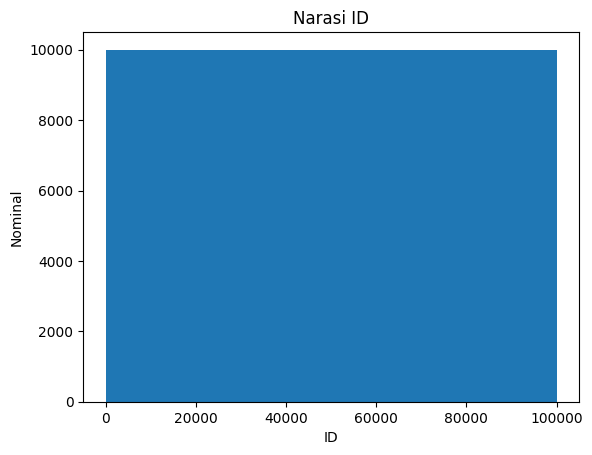

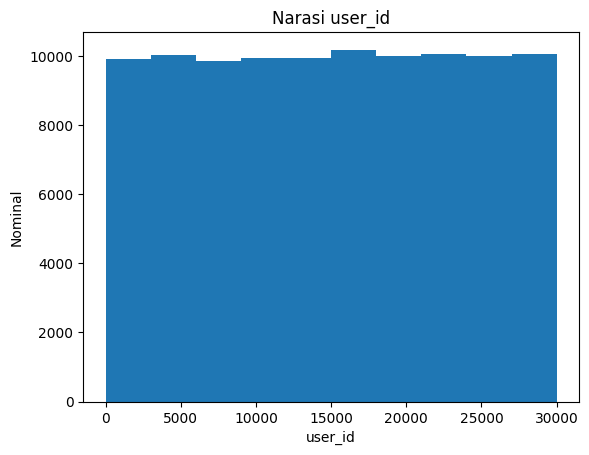

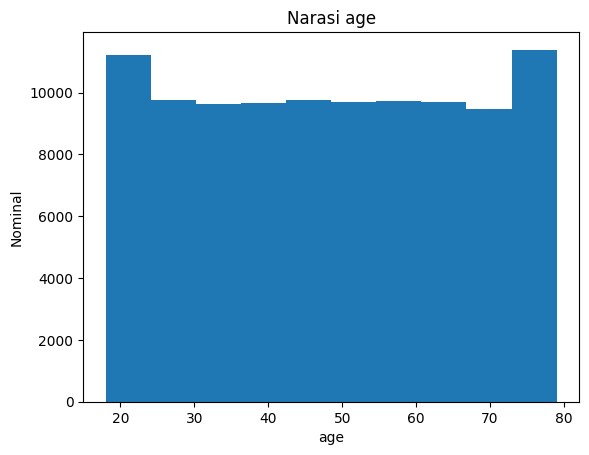

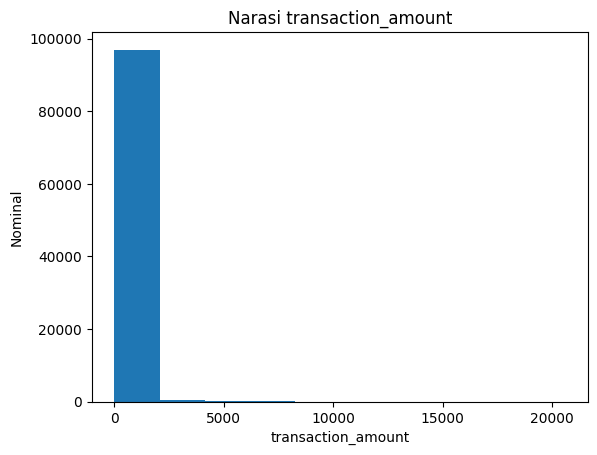

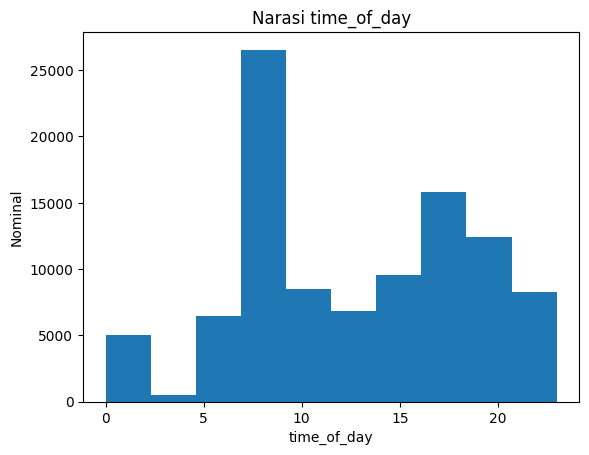

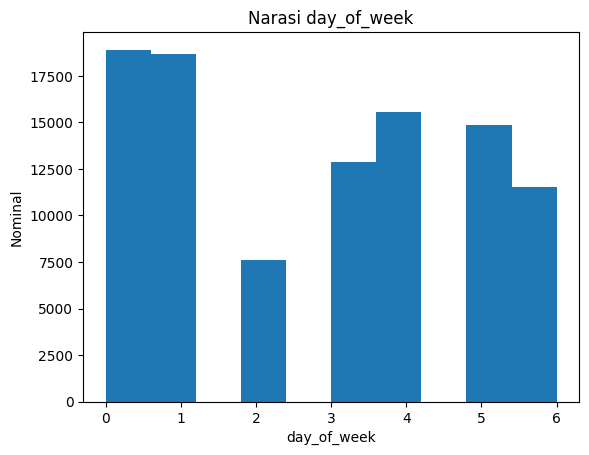

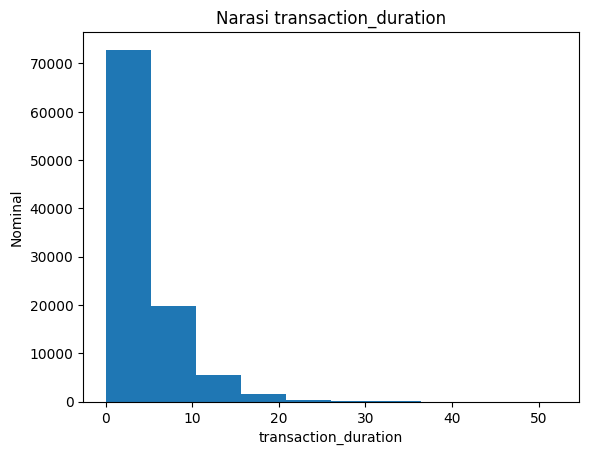

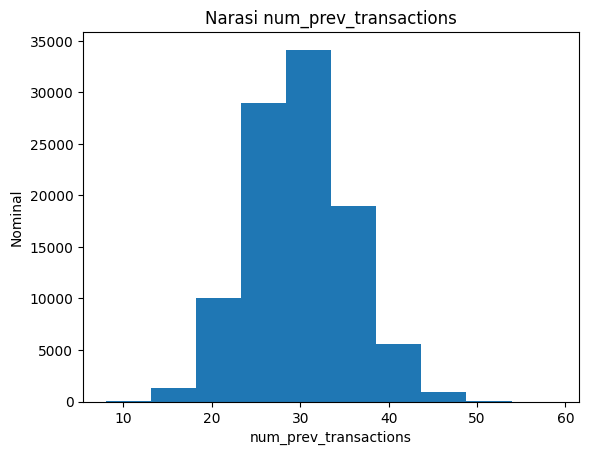

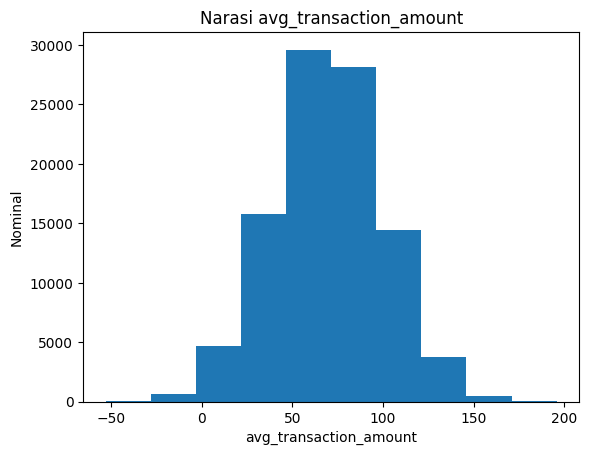

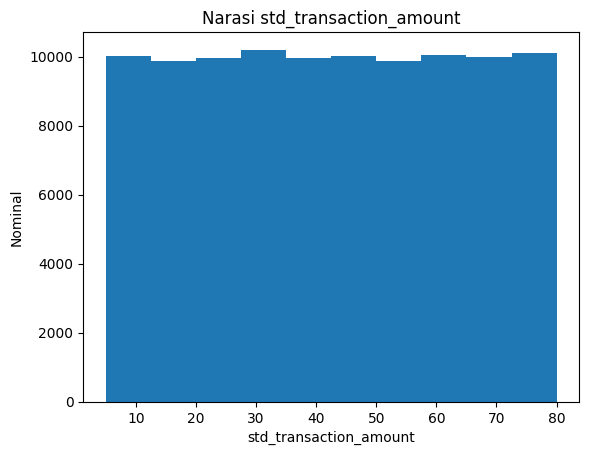

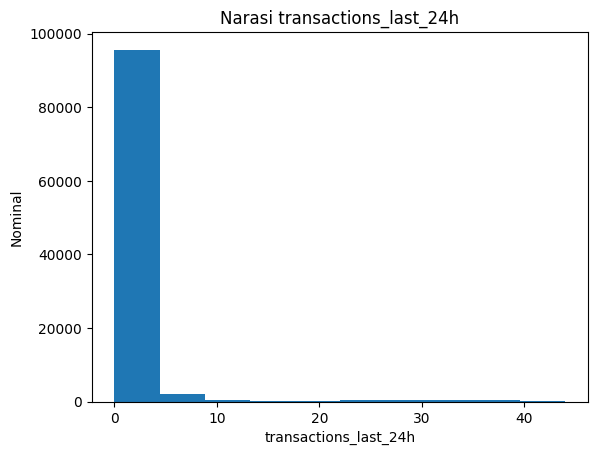

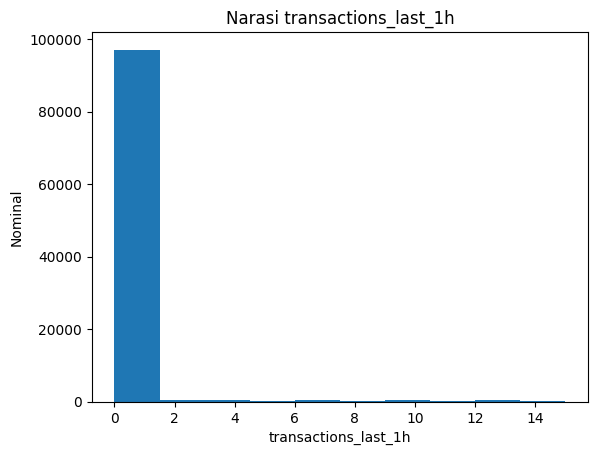

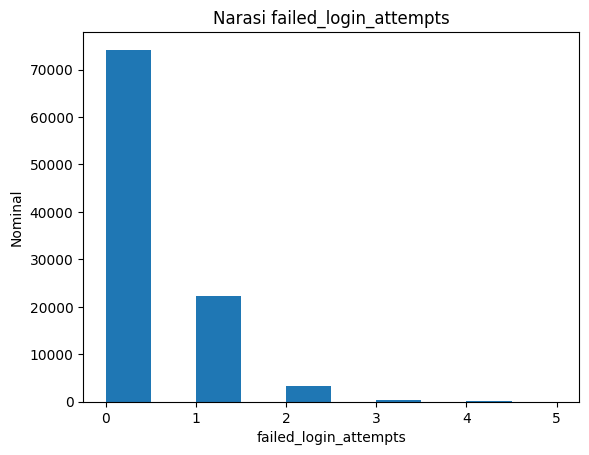

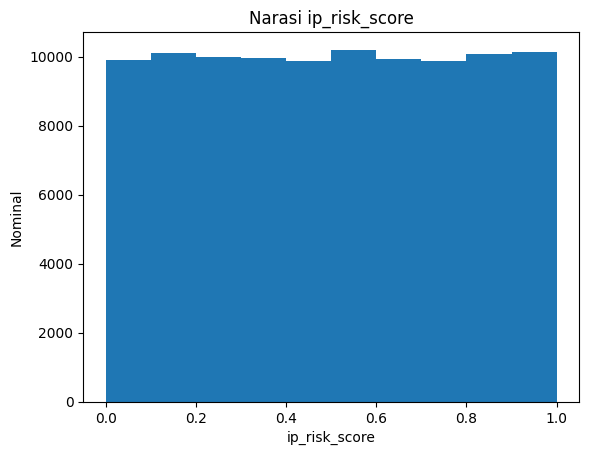

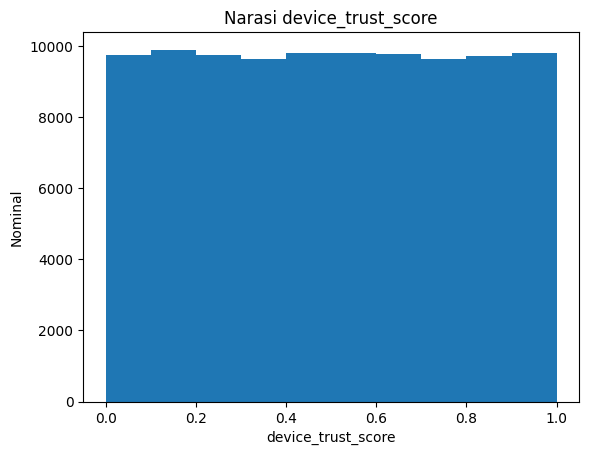

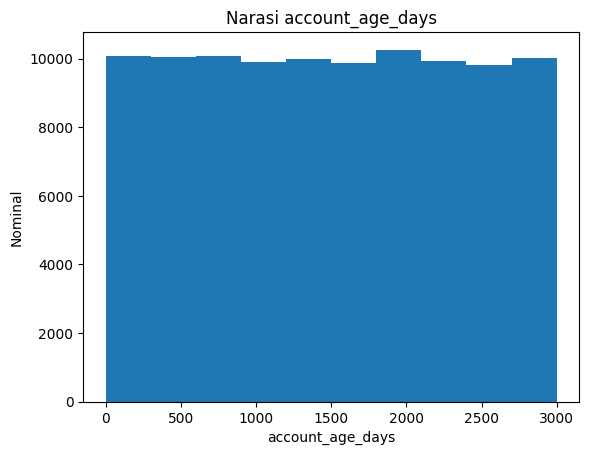

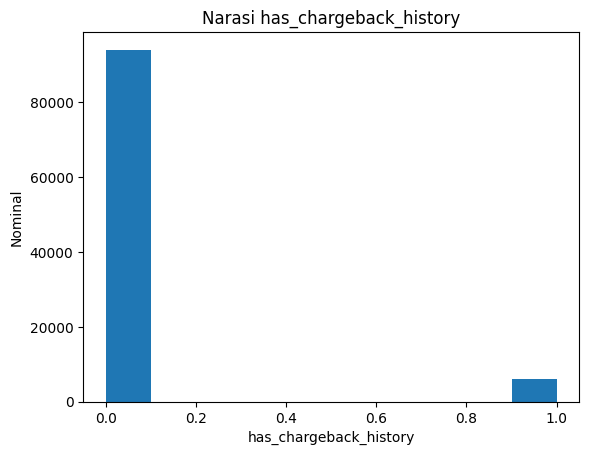

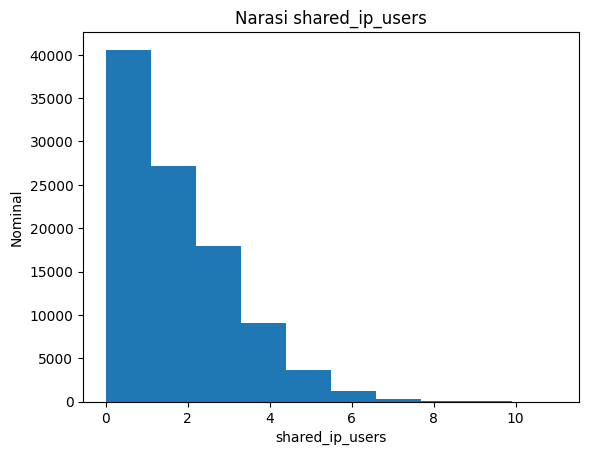

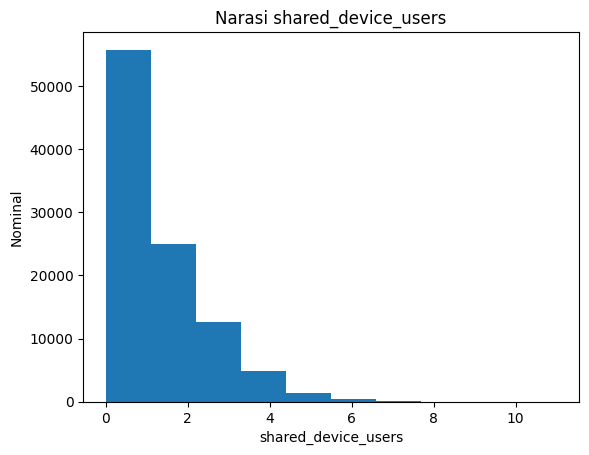

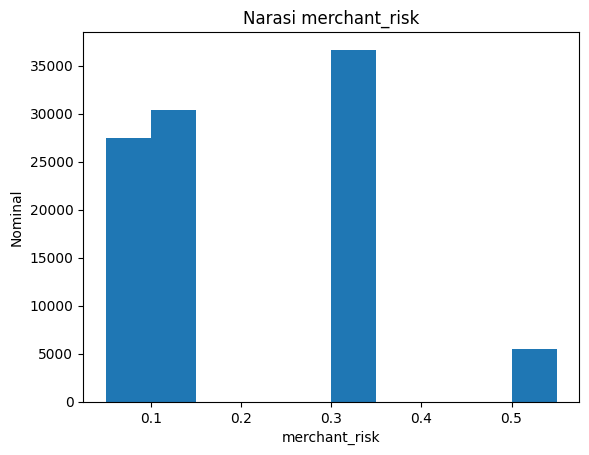

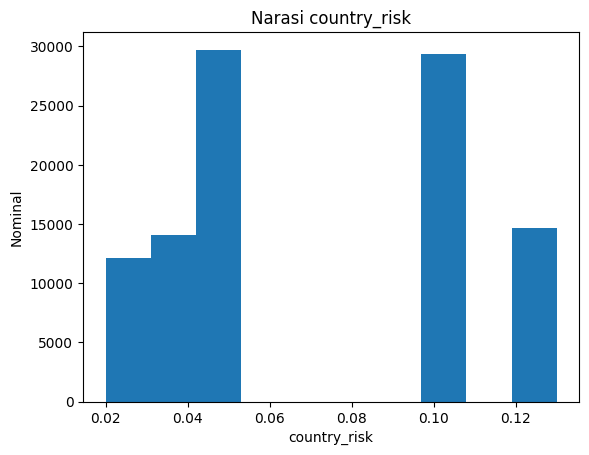

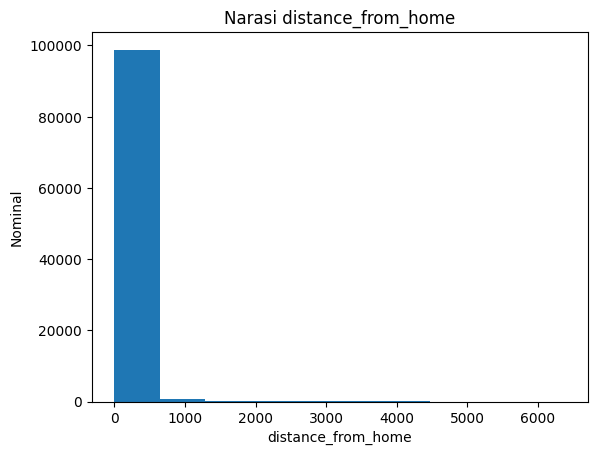

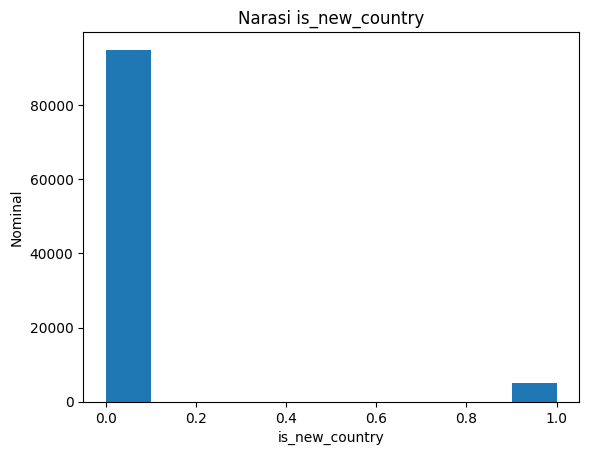

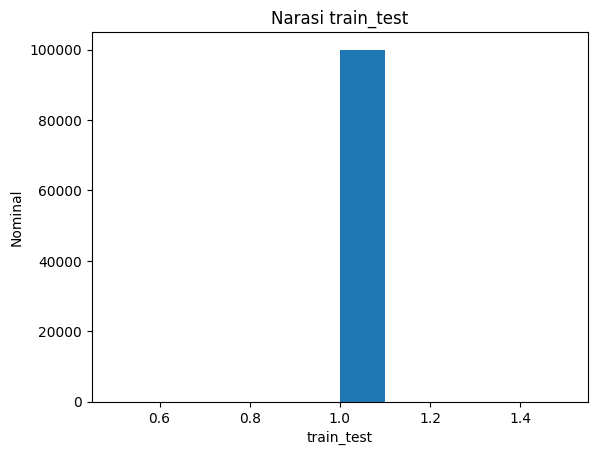

In [47]:
for i in train_num.columns:
    plt.hist(train_num[i])
    plt.title("Narasi "+ i)
    plt.ylabel("Nominal")
    plt.xlabel(i)
    plt.show()

                              ID   user_id       age  transaction_amount  \
ID                      1.000000  0.003268 -0.000095           -0.000248   
user_id                 0.003268  1.000000  0.001073           -0.000164   
age                    -0.000095  0.001073  1.000000            0.001944   
transaction_amount     -0.000248 -0.000164  0.001944            1.000000   
time_of_day             0.002132  0.001800 -0.000552           -0.001561   
day_of_week            -0.000436 -0.003165 -0.005084           -0.002341   
transaction_duration    0.001233  0.002276 -0.003512           -0.000660   
num_prev_transactions   0.005735  0.001946 -0.001081           -0.000776   
avg_transaction_amount  0.003691 -0.001898  0.001469           -0.003778   
std_transaction_amount -0.001581  0.003408 -0.001335            0.004352   
transactions_last_24h  -0.007794 -0.003295 -0.001439            0.526270   
transactions_last_1h   -0.003139 -0.003230 -0.001645            0.563724   
failed_login

<Axes: >

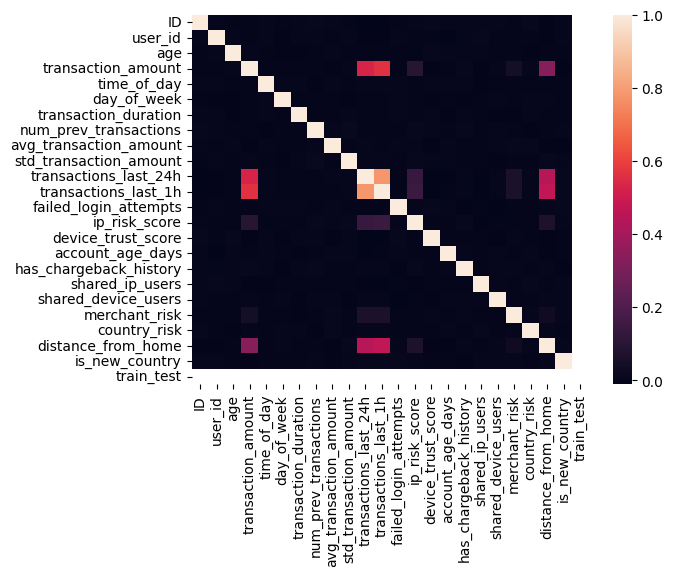

In [48]:
print(train_num.corr())
sns.heatmap(train_num.corr())

In [49]:
pd.pivot_table(train,index='is_fraud', values=train_num.columns, aggfunc='mean')

,ID,account_age_days,age,avg_transaction_amount,country_risk,day_of_week,device_trust_score,distance_from_home,failed_login_attempts,has_chargeback_history,...,shared_device_users,shared_ip_users,std_transaction_amount,time_of_day,train_test,transaction_amount,transaction_duration,transactions_last_1h,transactions_last_24h,user_id
is_fraud,,,,,,,,,,,,,,,,,,,,,
0,50049.687453,1499.734372,48.453221,69.951155,0.071309,2.784586,0.503288,113.199420,0.296127,0.053673,...,1.497124,1.982020,42.539650,12.771683,1.0,118.122489,3.989721,0.270111,1.945093,15032.293274
1,49694.453497,1482.684315,48.672140,70.082617,0.071418,2.757078,0.476332,143.013717,0.310164,0.100368,...,1.516067,2.114737,42.550681,12.760900,1.0,179.953522,4.059552,0.546999,2.617922,15088.068375


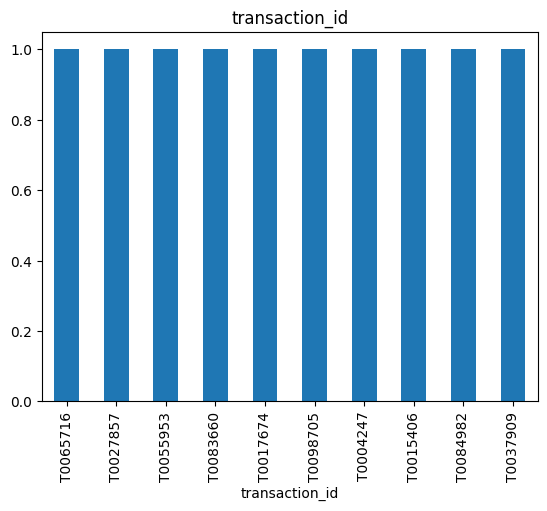

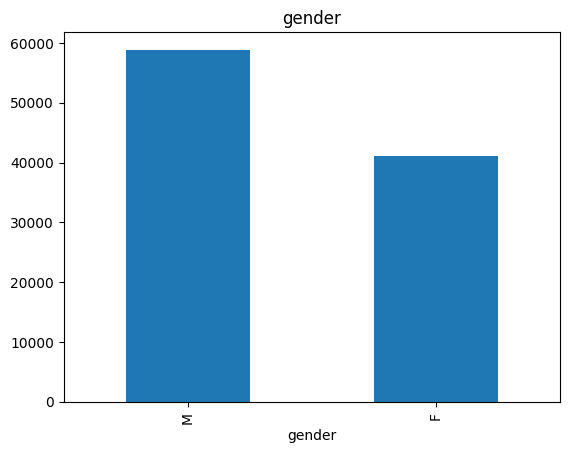

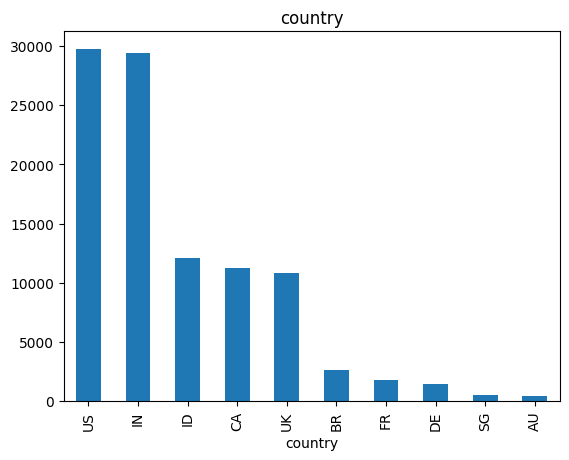

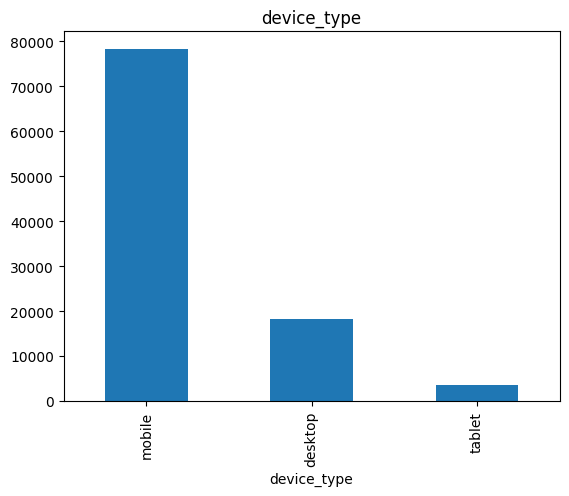

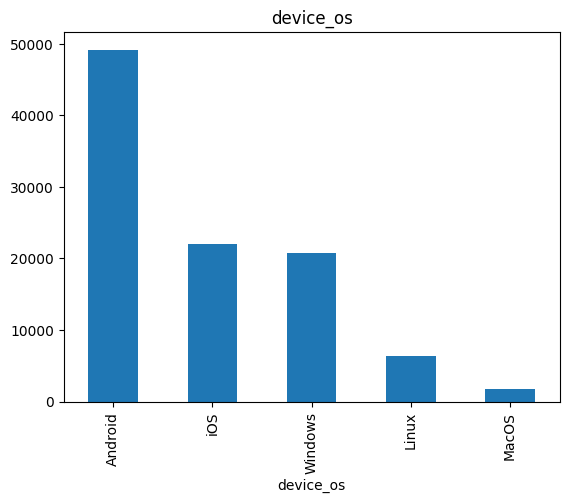

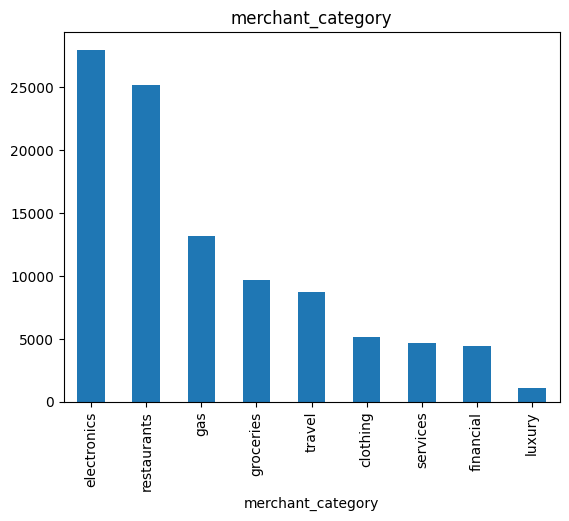

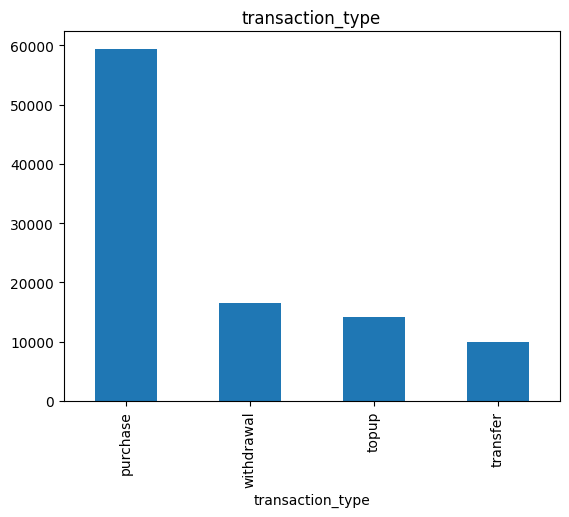

In [50]:
for i in train_cat.columns:
    train_cat[i].value_counts().head(10).plot(kind='bar', title=i)
    plt.show()

In [51]:
for col in train_cat.columns:
    print(f"\n=== {col} ===")
    display(
        pd.pivot_table(
            train,
            index=col,
            values="is_fraud",
            aggfunc="mean"
        ).sort_values("is_fraud", ascending=False)
    )



=== transaction_id ===


,is_fraud
transaction_id,
T0099984,1.0
T0018401,1.0
T0007127,1.0
T0013219,1.0
T0026771,1.0
...,...
T0099979,0.0
T0099980,0.0
T0099981,0.0



=== gender ===


,is_fraud
gender,
M,0.141464
F,0.141017



=== country ===


...

,is_fraud
device_os,
Windows,0.142072
MacOS,0.141804
iOS,0.141473
Android,0.141024
Linux,0.139848



=== merchant_category ===


,is_fraud
merchant_category,
luxury,0.162308
financial,0.162125
travel,0.148689
clothing,0.144623
electronics,0.144246
restaurants,0.138700
groceries,0.134651
gas,0.133055
services,0.132132



=== transaction_type ===


,is_fraud
transaction_type,
purchase,0.143514
topup,0.141416
withdrawal,0.136910
transfer,0.134974


In [52]:
trans_median = train['transaction_amount'].median()
train['transaction_amount'] = train['transaction_amount'].fillna(trans_median)

avg_trans_mean = train['avg_transaction_amount'].mean()
train['avg_transaction_amount'] = train['avg_transaction_amount'].fillna(avg_trans_mean)

avg_trust_score = train['device_trust_score'].mean()
train['device_trust_score'] = train['device_trust_score'].fillna(avg_trust_score)

train.isna().sum()


ID                        0
transaction_id            0
user_id                   0
age                       0
gender                    0
country                   0
device_type               0
device_os                 0
merchant_category         0
transaction_amount        0
transaction_type          0
time_of_day               0
day_of_week               0
transaction_duration      0
num_prev_transactions     0
avg_transaction_amount    0
std_transaction_amount    0
transactions_last_24h     0
transactions_last_1h      0
failed_login_attempts     0
ip_risk_score             0
device_trust_score        0
account_age_days          0
has_chargeback_history    0
shared_ip_users           0
shared_device_users       0
merchant_risk             0
country_risk              0
distance_from_home        0
is_new_country            0
is_fraud                  0
train_test                0
dtype: int64

In [53]:
#feautre engineering

for col in train_cat:
    fraud_rate = train.groupby(col)["is_fraud"].mean()
    all_data[col + "_fraud_rate"] = all_data[col].map(fraud_rate)


In [54]:
all_data["amount_vs_avg"] = (
    all_data["transaction_amount"] / (all_data["avg_transaction_amount"] + 1)
)

all_data["amount_zscore"] = (
    (all_data["transaction_amount"] - all_data["avg_transaction_amount"]) /
    (all_data["std_transaction_amount"] + 1)
)


In [55]:
all_data["tx_per_hour"] = all_data["transactions_last_1h"]
all_data["tx_per_day"] = all_data["transactions_last_24h"]

all_data["burst_activity"] = (
    all_data["transactions_last_1h"] /
    (all_data["transactions_last_24h"] + 1)
)


In [56]:
all_data["ip_device_risk_ratio"] = (
    all_data["ip_risk_score"] / (all_data["device_trust_score"] + 1e-3)
)

all_data["merchant_country_risk"] = (
    all_data["merchant_risk"] * all_data["country_risk"]
)



In [57]:
cat_cols = train_cat.columns.tolist()
num_cols = train_num.columns.tolist()


In [58]:
drop_cols = (
    ["ID", "transaction_id", "user_id"]
    + train_cat.columns.tolist()
)

train_fe = all_data.drop(columns=drop_cols)


In [59]:

train_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   age                           200000 non-null  int64  
 1   transaction_amount            195177 non-null  float64
 2   time_of_day                   200000 non-null  int64  
 3   day_of_week                   200000 non-null  int64  
 4   transaction_duration          200000 non-null  float64
 5   num_prev_transactions         200000 non-null  int64  
 6   avg_transaction_amount        195177 non-null  float64
 7   std_transaction_amount        200000 non-null  float64
 8   transactions_last_24h         200000 non-null  int64  
 9   transactions_last_1h          200000 non-null  int64  
 10  failed_login_attempts         200000 non-null  int64  
 11  ip_risk_score                 200000 non-null  float64
 12  device_trust_score            195177 non-nul

In [60]:
train_fe = train_fe.replace([np.inf, -np.inf], np.nan)

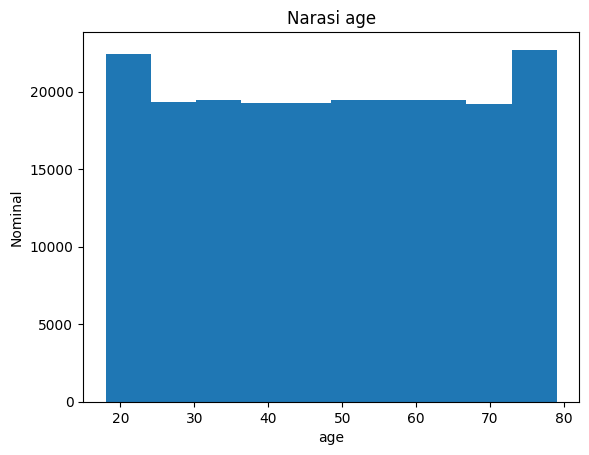

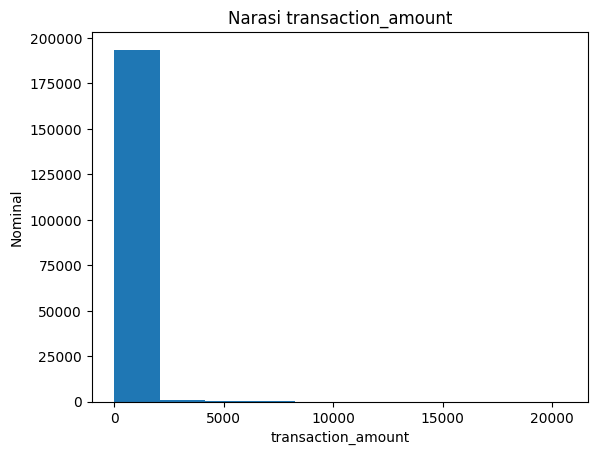

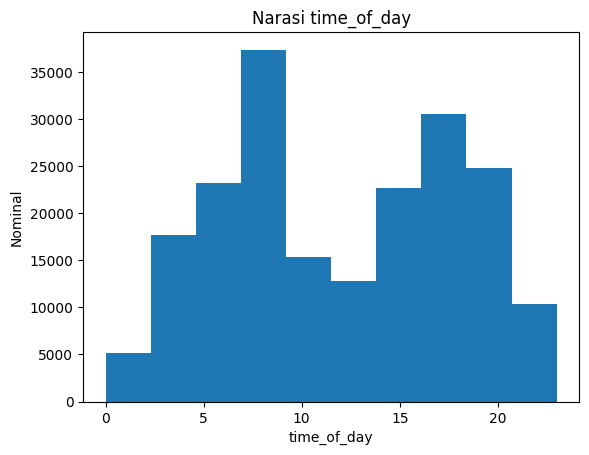

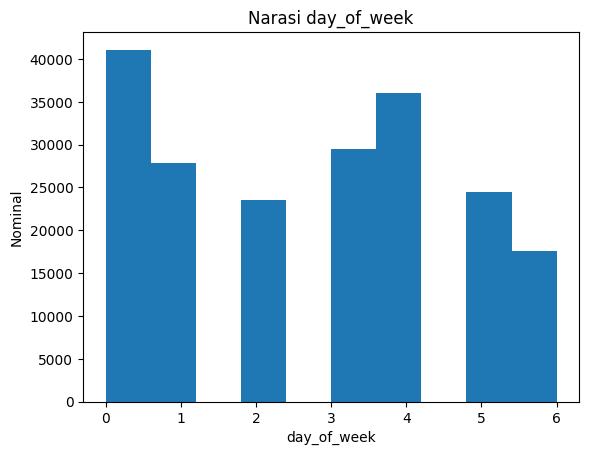

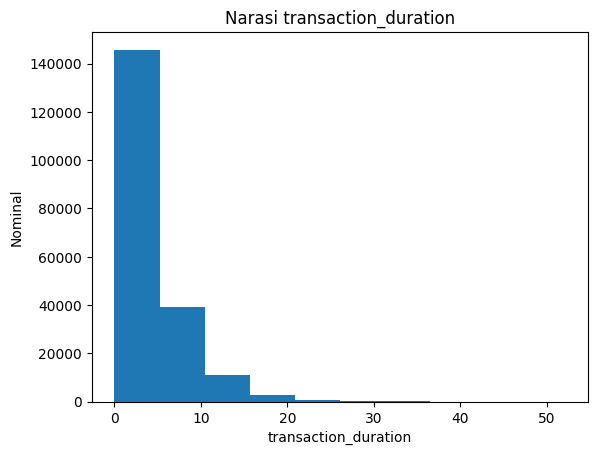

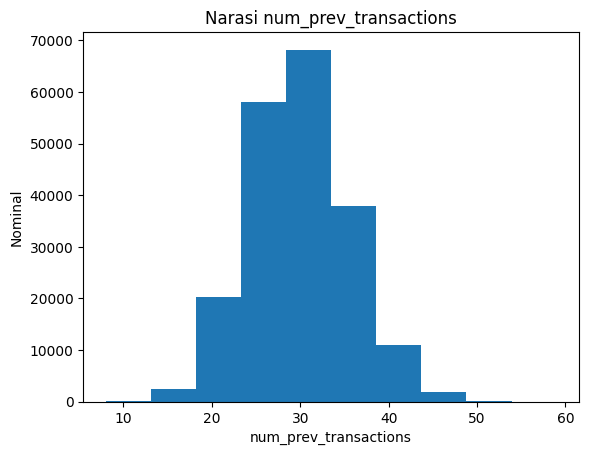

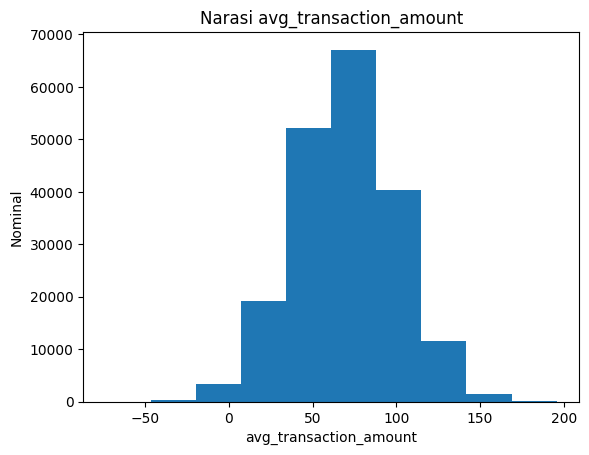

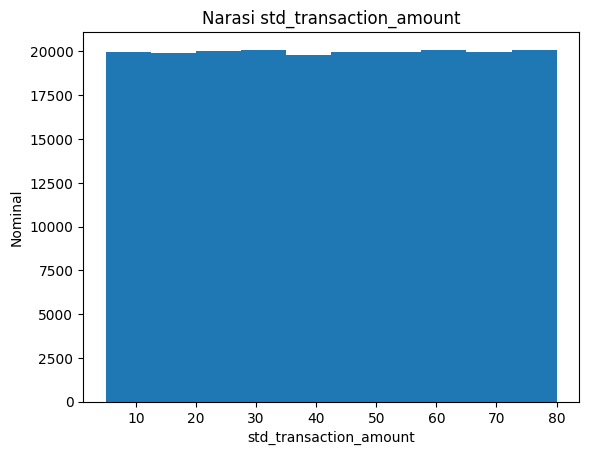

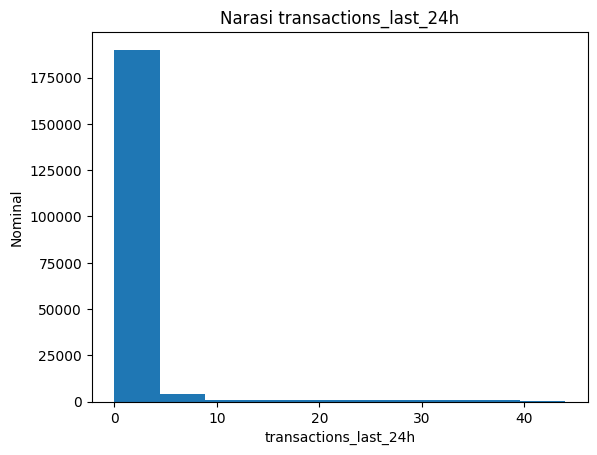

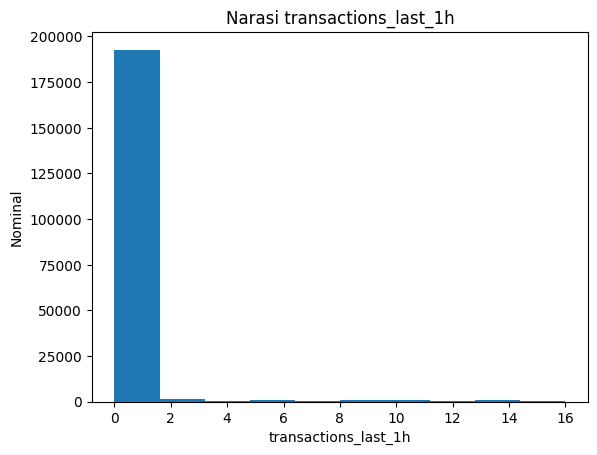

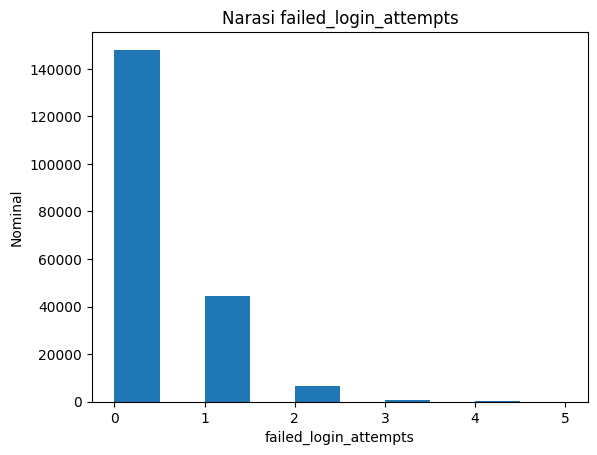

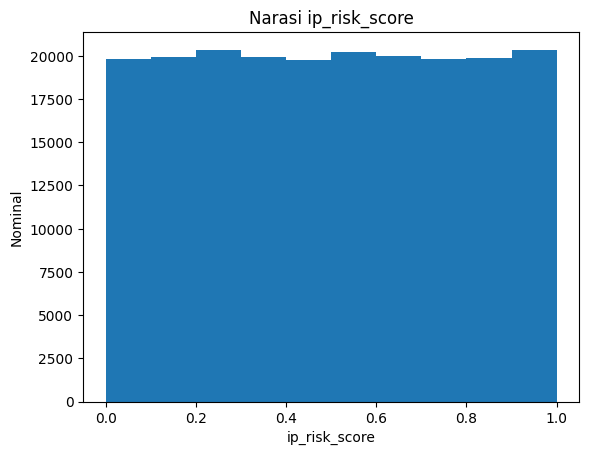

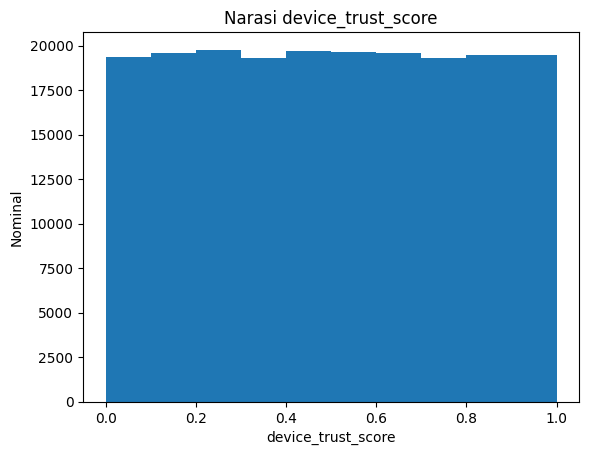

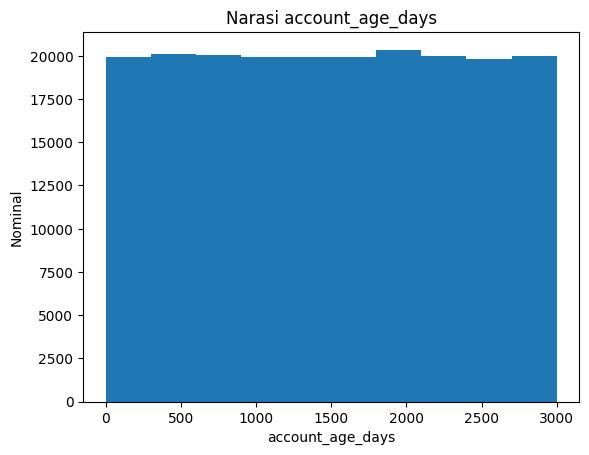

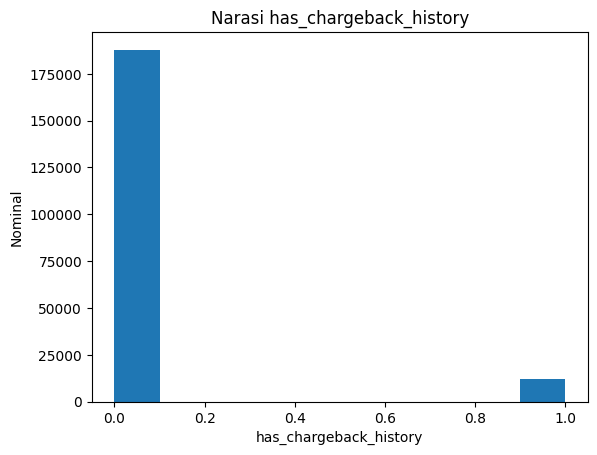

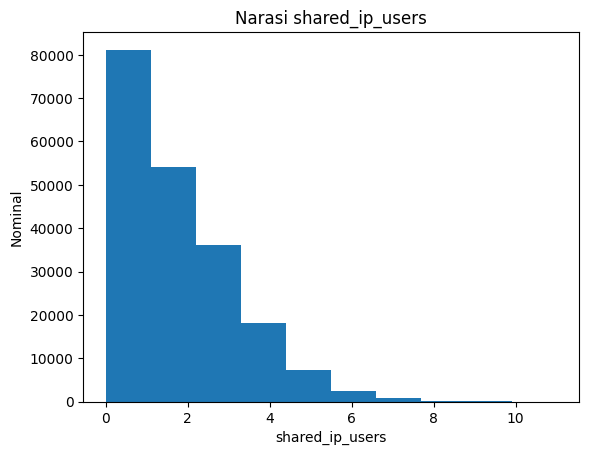

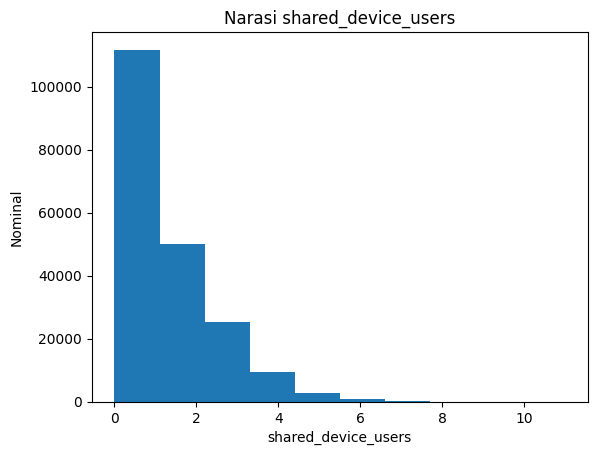

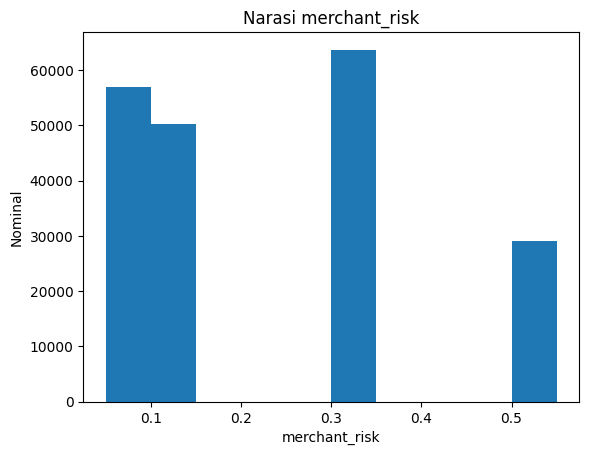

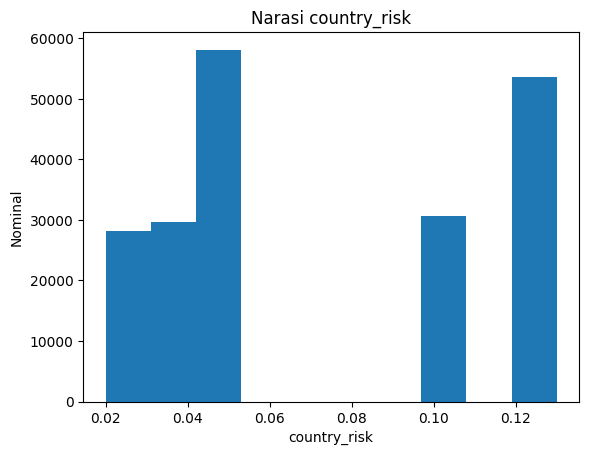

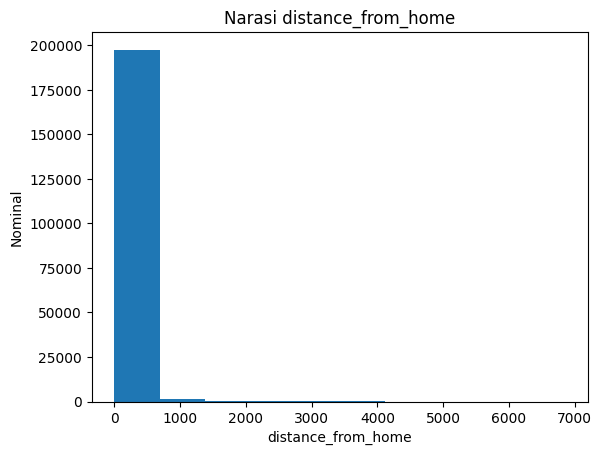

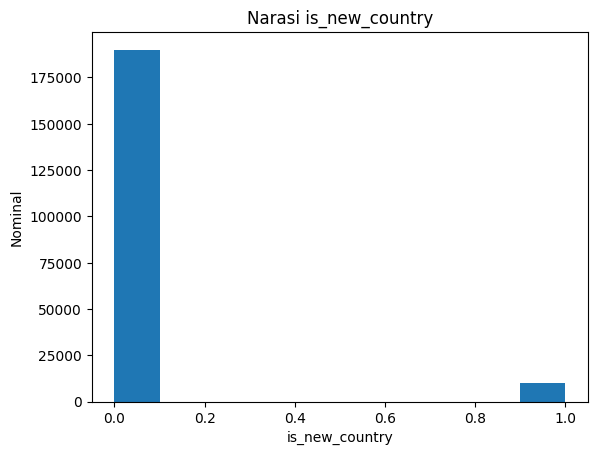

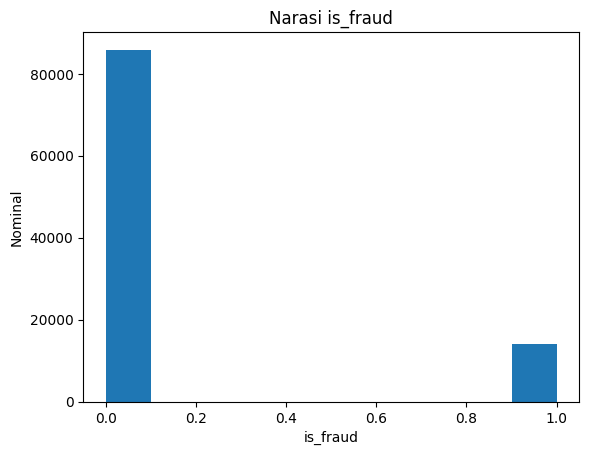

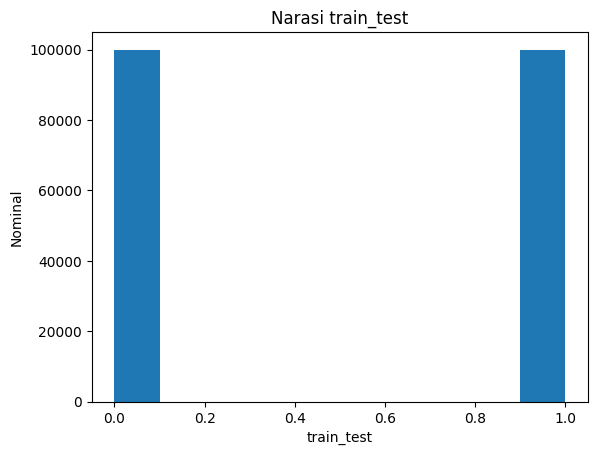

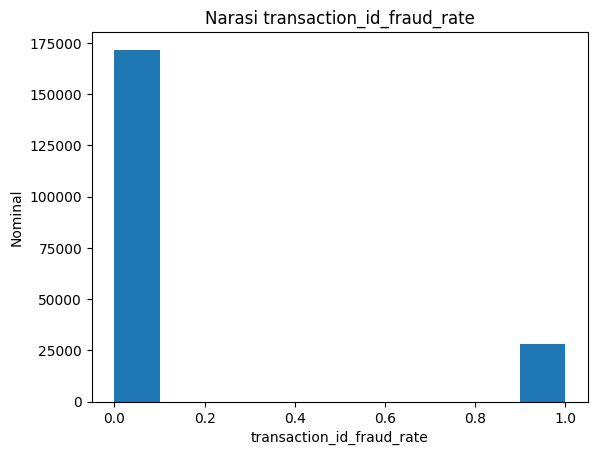

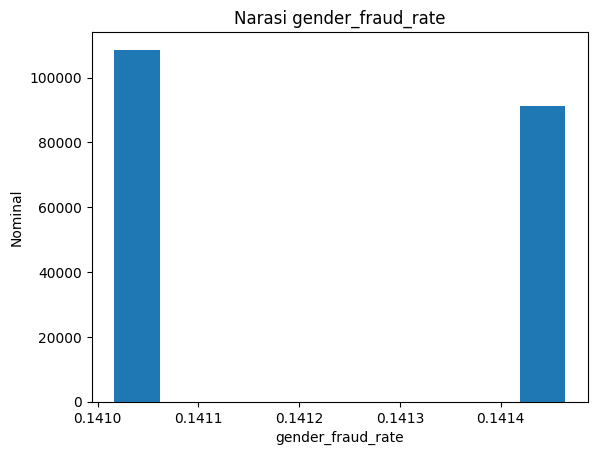

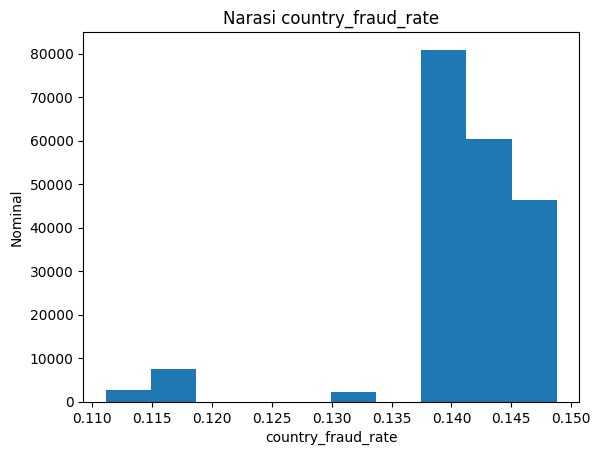

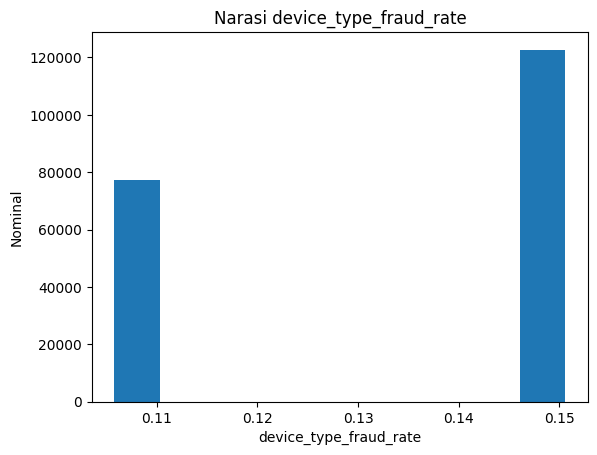

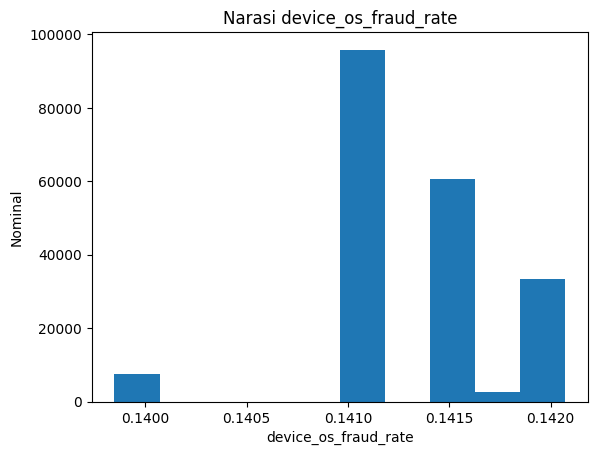

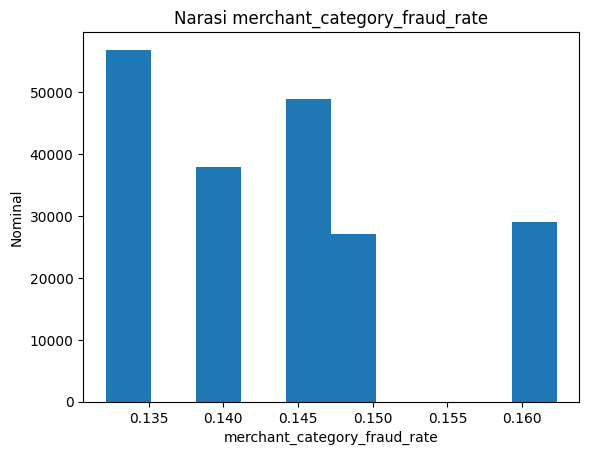

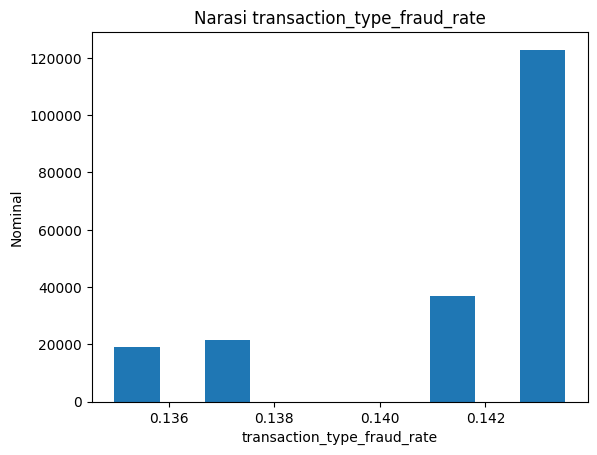

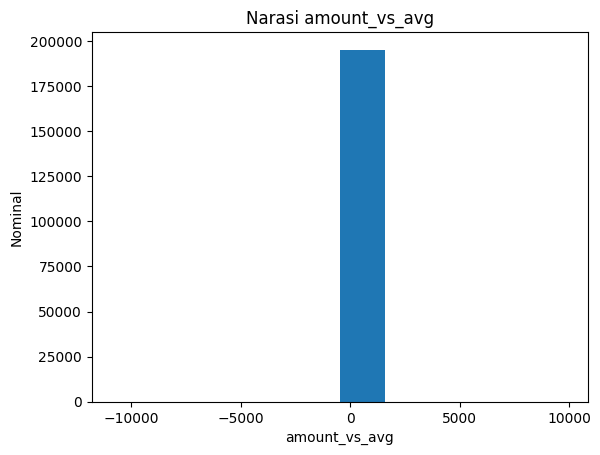

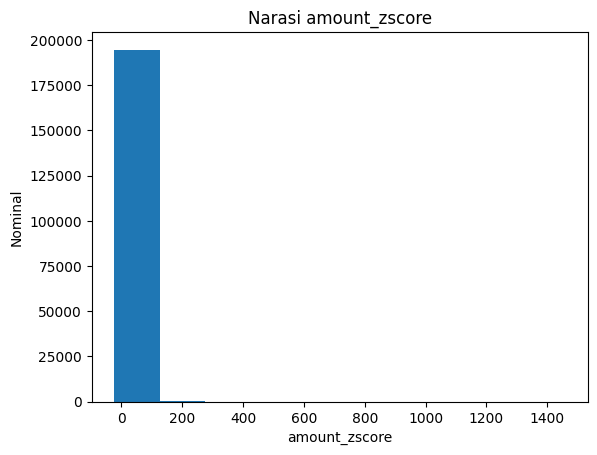

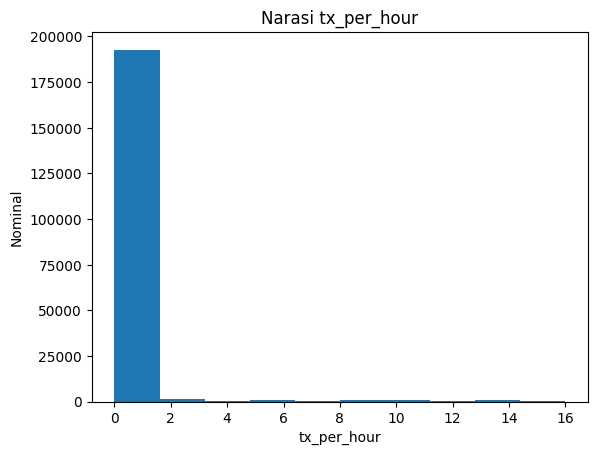

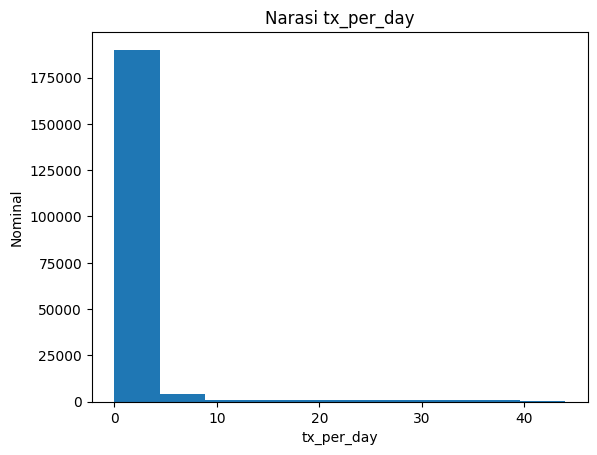

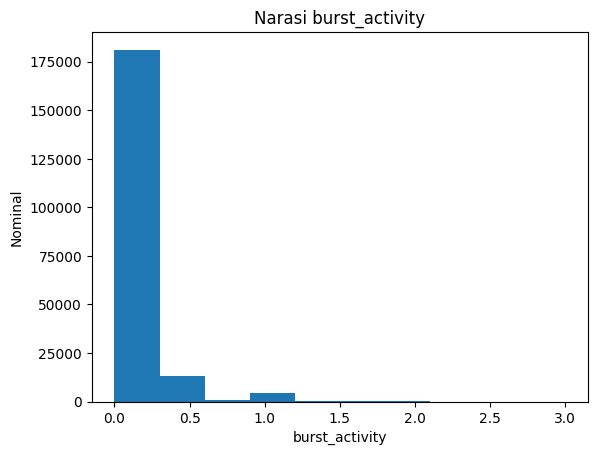

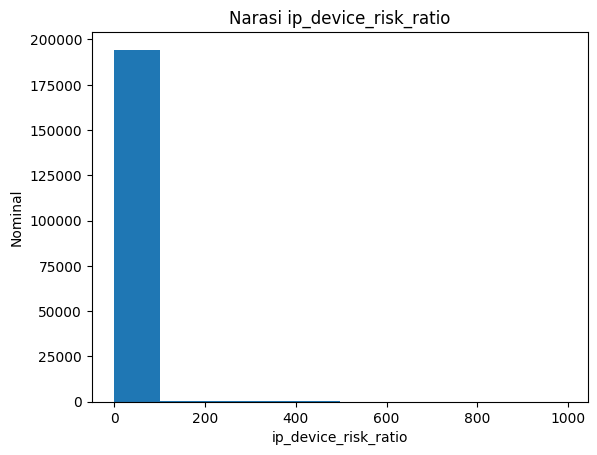

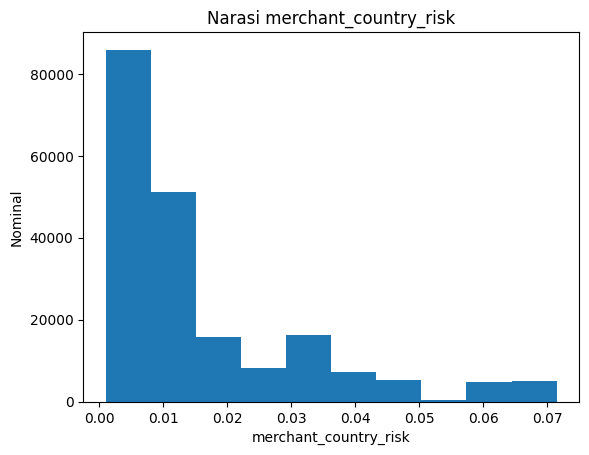

In [61]:
for i in train_fe.columns:
    plt.hist(train_fe[i])
    plt.title("Narasi "+ i)
    plt.ylabel("Nominal")
    plt.xlabel(i)
    plt.show()

In [62]:
train_fe

,age,transaction_amount,time_of_day,day_of_week,transaction_duration,num_prev_transactions,avg_transaction_amount,std_transaction_amount,transactions_last_24h,transactions_last_1h,...,device_os_fraud_rate,merchant_category_fraud_rate,transaction_type_fraud_rate,amount_vs_avg,amount_zscore,tx_per_hour,tx_per_day,burst_activity,ip_device_risk_ratio,merchant_country_risk
0,35,17.70000,18,1,3.04,34,91.01,56.68,0,0,...,0.141024,0.144623,0.143514,0.192370,-1.270978,0,0,0.0,0.584383,0.0040
1,54,NaN,7,3,0.33,28,NaN,50.11,1,0,...,0.141024,0.138700,0.143514,NaN,NaN,0,1,0.0,NaN,0.0120
2,35,5.20000,15,5,7.85,31,111.05,20.79,3,0,...,0.141473,0.138700,0.143514,0.046408,-4.857733,0,3,0.0,3.333333,0.0060
3,23,180.70000,18,3,4.71,32,27.88,73.32,3,0,...,0.141024,0.144246,0.143514,6.256925,2.056243,0,3,0.0,2.677419,0.0150
4,32,35.45000,8,3,1.56,21,81.34,73.28,0,0,...,0.141024,0.133055,0.143514,0.430532,-0.617798,0,0,0.0,1.467116,0.0020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,19,4824.36991,3,5,4.17,27,8.25,21.33,19,6,...,0.141024,0.148689,0.143514,521.553504,215.679351,6,19,0.3,4.381188,0.0175
199996,38,1.79000,5,4,0.33,32,102.59,74.59,0,0,...,0.141473,0.148689,0.134974,0.017280,-1.333510,0,0,0.0,0.410714,0.0420
199997,22,67.97000,8,2,7.74,24,67.19,73.69,1,0,...,0.141024,0.133055,0.143514,0.996774,0.010443,0,1,0.0,0.755946,0.0025
199998,37,50.48000,17,0,0.35,36,73.00,14.70,1,0,...,0.141024,0.162125,0.141416,0.682162,-1.434395,0,1,0.0,0.925651,0.0650


In [63]:
# Normalisasai liat ga terdsitribusi normal

for col in [
    "transaction_amount",
    "avg_transaction_amount",
    "std_transaction_amount",
    "transaction_duration",
    "num_prev_transactions",
    "transactions_last_24h",
    "transactions_last_1h",
    "failed_login_attempts",
    "shared_ip_users",
    "shared_device_users",
    "account_age_days",
    "amount_vs_avg",
    "amount_zscore",
    "burst_activity",
    "ip_device_risk_ratio"
]:
    train_fe[col + "_log"] = np.log1p(train_fe[col])


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(uf

In [64]:
X_train = train_fe[train_fe.train_test == 1].drop(["train_test", "is_fraud"], axis=1)
X_test  = train_fe[train_fe.train_test == 0].drop(["train_test", "is_fraud"], axis=1)

y_train = train_fe.loc[train_fe.train_test == 1, "is_fraud"]


In [65]:
binary_cols = [
    col for col in X_train.columns
    if set(X_train[col].dropna().unique()).issubset({0, 1})
]

for i in binary_cols:
    print(i)

has_chargeback_history
is_new_country
transaction_id_fraud_rate


In [66]:
from sklearn.preprocessing import StandardScaler

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

binary_cols = [
    "has_chargeback_history",
    "is_new_country",
    "transaction_id_fraud_rate"
]

scale_cols = [col for col in X_train.columns if col not in binary_cols]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])


In [67]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   age                           100000 non-null  float64
 1   transaction_amount            97581 non-null   float64
 2   time_of_day                   100000 non-null  float64
 3   day_of_week                   100000 non-null  float64
 4   transaction_duration          100000 non-null  float64
 5   num_prev_transactions         100000 non-null  float64
 6   avg_transaction_amount        97581 non-null   float64
 7   std_transaction_amount        100000 non-null  float64
 8   transactions_last_24h         100000 non-null  float64
 9   transactions_last_1h          100000 non-null  float64
 10  failed_login_attempts         100000 non-null  float64
 11  ip_risk_score                 100000 non-null  float64
 12  device_trust_score            97581 non-null   flo

In [68]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

import numpy as np

x_tr  = np.nan_to_num(X_tr.values,  nan=0.0, posinf=0.0, neginf=0.0)
x_val = np.nan_to_num(X_val.values, nan=0.0, posinf=0.0, neginf=0.0)

# y_tr  = y_tr.astype(int)
# y_val = y_val.astype(int)


from logistic_regression import LogisticRegressionScratch

model = LogisticRegressionScratch(
    learning_rate=0.001,
    n_iterations=8000,
    regularization="l2",
    lambda_=0.001,
    verbose=True
)

model.fit(x_tr, y_tr)


from sklearn.metrics import roc_auc_score

y_val_prob = model.predict_proba(x_val)

roc_auc = roc_auc_score(y_val, y_val_prob)
print(f"ROC AUC (Validation): {roc_auc:.4f}")



Iteration 0/8000 - Cost: 0.6930
Iteration 100/8000 - Cost: 0.6794
Iteration 200/8000 - Cost: 0.6665
Iteration 300/8000 - Cost: 0.6543
Iteration 400/8000 - Cost: 0.6426
Iteration 500/8000 - Cost: 0.6315
Iteration 600/8000 - Cost: 0.6209
Iteration 700/8000 - Cost: 0.6108
Iteration 800/8000 - Cost: 0.6011
Iteration 900/8000 - Cost: 0.5919
Iteration 1000/8000 - Cost: 0.5830
Iteration 1100/8000 - Cost: 0.5745
Iteration 1200/8000 - Cost: 0.5664
Iteration 1300/8000 - Cost: 0.5586
Iteration 1400/8000 - Cost: 0.5511
Iteration 1500/8000 - Cost: 0.5439
Iteration 1600/8000 - Cost: 0.5370
Iteration 1700/8000 - Cost: 0.5303
Iteration 1800/8000 - Cost: 0.5239
Iteration 1900/8000 - Cost: 0.5178
Iteration 2000/8000 - Cost: 0.5119
Iteration 2100/8000 - Cost: 0.5062
Iteration 2200/8000 - Cost: 0.5007
Iteration 2300/8000 - Cost: 0.4954
Iteration 2400/8000 - Cost: 0.4903
Iteration 2500/8000 - Cost: 0.4853
Iteration 2600/8000 - Cost: 0.4806
Iteration 2700/8000 - Cost: 0.4759
Iteration 2800/8000 - Cost: 0.47

In [69]:
# full train
x_train_full = np.nan_to_num(
    X_train_scaled.values,
    nan=0.0, posinf=0.0, neginf=0.0
)
y_train_full = y_train.copy()

model_final = LogisticRegressionScratch(
    learning_rate=0.001,
    n_iterations=8000,
    regularization="l2",
    lambda_=0.001,
    verbose=True
)

model_final.fit(x_train_full, y_train_full)


Iteration 0/8000 - Cost: 0.6930
Iteration 100/8000 - Cost: 0.6794
Iteration 200/8000 - Cost: 0.6665
Iteration 300/8000 - Cost: 0.6542
Iteration 400/8000 - Cost: 0.6426
Iteration 500/8000 - Cost: 0.6315
Iteration 600/8000 - Cost: 0.6208
Iteration 700/8000 - Cost: 0.6107
Iteration 800/8000 - Cost: 0.6010
Iteration 900/8000 - Cost: 0.5918
Iteration 1000/8000 - Cost: 0.5829
Iteration 1100/8000 - Cost: 0.5744
Iteration 1200/8000 - Cost: 0.5663
Iteration 1300/8000 - Cost: 0.5585
Iteration 1400/8000 - Cost: 0.5510
Iteration 1500/8000 - Cost: 0.5438
Iteration 1600/8000 - Cost: 0.5369
Iteration 1700/8000 - Cost: 0.5303
Iteration 1800/8000 - Cost: 0.5239
Iteration 1900/8000 - Cost: 0.5177
Iteration 2000/8000 - Cost: 0.5118
Iteration 2100/8000 - Cost: 0.5061
Iteration 2200/8000 - Cost: 0.5006
Iteration 2300/8000 - Cost: 0.4953
Iteration 2400/8000 - Cost: 0.4902
Iteration 2500/8000 - Cost: 0.4853
Iteration 2600/8000 - Cost: 0.4805
Iteration 2700/8000 - Cost: 0.4759
Iteration 2800/8000 - Cost: 0.47

LogisticRegressionScratch(learning_rate=0.001, n_iterations=8000, regularization=l2, lambda_=0.001)

In [ ]:

# test
x_test_final = np.nan_to_num(
    X_test_scaled.values,
    nan=0.0, posinf=0.0, neginf=0.0
)

y_test_prob = model_final.predict_proba(x_test_final)
y_test_pred = model_final.predict(x_test_final)


submission = pd.DataFrame({
    "ID": test["ID"].values,
    "is_fraud": y_test_prob
})

submission.to_csv("submissionFinal2.csv", index=False)
print("submission.csv siap dikumpulkan 🚀")

save_model(model_final, "saved_models/logistic_regression_model.pkl")


submission.csv siap dikumpulkan 🚀


In [71]:
leak_cols = [c for c in X_train_scaled.columns if "fraud_rate" in c]

X_train_noleak = X_train_scaled.drop(columns=leak_cols)
X_test_noleak  = X_test_scaled.drop(columns=leak_cols)

X_train_noleak

,age,transaction_amount,time_of_day,day_of_week,transaction_duration,num_prev_transactions,avg_transaction_amount,std_transaction_amount,transactions_last_24h,transactions_last_1h,...,transactions_last_24h_log,transactions_last_1h_log,failed_login_attempts_log,shared_ip_users_log,shared_device_users_log,account_age_days_log,amount_vs_avg_log,amount_zscore_log,burst_activity_log,ip_device_risk_ratio_log
0,-0.753638,-0.290281,0.909759,-0.862431,-0.239131,0.730548,0.702247,0.652981,-0.514229,-0.211191,...,-1.353887,-0.303794,1.468876,-0.558024,-0.191217,-0.045095,-0.926200,NaN,-0.324396,-0.550183
1,0.308284,NaN,-1.003751,0.106212,-0.914468,-0.363109,NaN,0.349554,-0.262175,-0.211191,...,-0.245380,-0.303794,-0.573220,-0.558024,-0.191217,0.531764,NaN,NaN,-0.324396,NaN
2,-0.753638,-0.323522,0.387893,1.074855,0.959530,0.183720,1.371108,-1.004550,0.241935,-0.211191,...,0.863127,-0.303794,-0.573220,0.234752,0.598654,0.452258,-1.113443,NaN,-0.324396,0.776027
3,-1.424326,0.143191,0.909759,0.106212,0.177036,0.365996,-1.404799,1.421477,0.241935,-0.211191,...,0.863127,-0.303794,-0.573220,-0.558024,-0.191217,-3.620321,1.663503,0.479490,-0.324396,0.559691
4,-0.921310,-0.243077,-0.829795,0.106212,-0.607950,-1.639041,0.379498,1.419630,-0.514229,-0.211191,...,-1.353887,-0.303794,-0.573220,0.797235,-0.191217,0.230156,-0.665076,-1.019850,-0.324396,0.033551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.314316,-0.316954,0.039982,-1.346753,0.184512,-0.180832,-0.461585,-0.507614,-0.010120,0.471766,...,0.403055,1.455186,-0.573220,-1.913283,-1.541510,0.371074,-0.997879,NaN,1.665293,-0.655859
99996,-0.641857,-0.209836,-0.307929,-1.346753,0.196972,2.006481,0.983275,-0.160313,-0.010120,-0.211191,...,0.403055,-0.303794,-0.573220,1.891410,0.598654,-0.500923,-0.618804,NaN,-0.324396,0.255050
99997,-1.647888,-0.219569,1.083715,1.074855,-0.969292,3.100138,0.457265,-1.674675,-0.010120,-0.211191,...,0.403055,-0.303794,-0.573220,-0.558024,-1.541510,0.317572,-0.575176,NaN,-0.324396,-1.080237
99998,-0.809529,NaN,-1.177706,-1.346753,-0.426032,1.824205,NaN,0.290901,-0.262175,-0.211191,...,-0.245380,-0.303794,-0.573220,-0.558024,0.598654,-0.200139,NaN,NaN,-0.324396,NaN


In [ ]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_noleak,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

import numpy as np

x_tr  = np.nan_to_num(X_tr.values,  nan=0.0, posinf=0.0, neginf=0.0)
x_val = np.nan_to_num(X_val.values, nan=0.0, posinf=0.0, neginf=0.0)

# y_tr  = y_tr.astype(int)
# y_val = y_val.astype(int)


from logistic_regression import LogisticRegressionScratch

model = LogisticRegressionScratch(
    learning_rate=0.01,
    n_iterations=5000,
    regularization="l2",
    lambda_=0.01,
    verbose=True
)

model.fit(x_tr, y_tr)


from sklearn.metrics import roc_auc_score

y_val_prob = model.predict_proba(x_val)

roc_auc = roc_auc_score(y_val, y_val_prob)
print(f"ROC AUC (Validation): {roc_auc:.4f}")



Iteration 0/5000 - Cost: 0.6918
Iteration 100/5000 - Cost: 0.5888
Iteration 200/5000 - Cost: 0.5264
Iteration 300/5000 - Cost: 0.4871
Iteration 400/5000 - Cost: 0.4617
Iteration 500/5000 - Cost: 0.4447
Iteration 600/5000 - Cost: 0.4332
Iteration 700/5000 - Cost: 0.4251
Iteration 800/5000 - Cost: 0.4193
Iteration 900/5000 - Cost: 0.4152
Iteration 1000/5000 - Cost: 0.4121
Iteration 1100/5000 - Cost: 0.4098
Iteration 1200/5000 - Cost: 0.4081
Iteration 1300/5000 - Cost: 0.4068
Iteration 1400/5000 - Cost: 0.4058
Iteration 1500/5000 - Cost: 0.4051
Iteration 1600/5000 - Cost: 0.4045
Iteration 1700/5000 - Cost: 0.4040
Iteration 1800/5000 - Cost: 0.4036
Iteration 1900/5000 - Cost: 0.4033
Iteration 2000/5000 - Cost: 0.4031
Iteration 2100/5000 - Cost: 0.4029
Iteration 2200/5000 - Cost: 0.4027
Iteration 2300/5000 - Cost: 0.4026
Iteration 2400/5000 - Cost: 0.4024
Iteration 2500/5000 - Cost: 0.4023
Iteration 2600/5000 - Cost: 0.4022
Iteration 2700/5000 - Cost: 0.4021
Iteration 2800/5000 - Cost: 0.40

In [ ]:
# full train
x_train_full = np.nan_to_num(
    X_train_noleak.values,
    nan=0.0, posinf=0.0, neginf=0.0
)
y_train_full = y_train.copy()

model_final = LogisticRegressionScratch(
    learning_rate=0.01,
    n_iterations=5000,
    regularization="l2",
    lambda_=0.01,
    verbose=True
)

model_final.fit(x_train_full, y_train_full)


Iteration 0/5000 - Cost: 0.6918
Iteration 100/5000 - Cost: 0.5887
Iteration 200/5000 - Cost: 0.5262
Iteration 300/5000 - Cost: 0.4870
Iteration 400/5000 - Cost: 0.4616
Iteration 500/5000 - Cost: 0.4446
Iteration 600/5000 - Cost: 0.4330
Iteration 700/5000 - Cost: 0.4249
Iteration 800/5000 - Cost: 0.4192
Iteration 900/5000 - Cost: 0.4150
Iteration 1000/5000 - Cost: 0.4120
Iteration 1100/5000 - Cost: 0.4097
Iteration 1200/5000 - Cost: 0.4080
Iteration 1300/5000 - Cost: 0.4067
Iteration 1400/5000 - Cost: 0.4057
Iteration 1500/5000 - Cost: 0.4050
Iteration 1600/5000 - Cost: 0.4044
Iteration 1700/5000 - Cost: 0.4039
Iteration 1800/5000 - Cost: 0.4035
Iteration 1900/5000 - Cost: 0.4032
Iteration 2000/5000 - Cost: 0.4030
Iteration 2100/5000 - Cost: 0.4028
Iteration 2200/5000 - Cost: 0.4026
Iteration 2300/5000 - Cost: 0.4025
Iteration 2400/5000 - Cost: 0.4023
Iteration 2500/5000 - Cost: 0.4022
Iteration 2600/5000 - Cost: 0.4022
Iteration 2700/5000 - Cost: 0.4021
Iteration 2800/5000 - Cost: 0.40

LogisticRegressionScratch(learning_rate=0.01, n_iterations=5000, regularization=l1, lambda_=0.01)

In [ ]:

# test
x_test_final = np.nan_to_num(
    X_test_noleak.values,
    nan=0.0, posinf=0.0, neginf=0.0
)

y_test_prob = model_final.predict_proba(x_test_final)
y_test_pred = model_final.predict(x_test_final)


submission = pd.DataFrame({
    "ID": test["ID"].values,
    "is_fraud": y_test_prob
})

submission.to_csv("submissionFinalNoLeaking3.csv", index=False)
print("submission.csv siap dikumpulkan 🚀")

save_model(model_final, "saved_models/logistic_regression_model_noleak.pkl")

submission.csv siap dikumpulkan 🚀
